In [ ]:
Project AI-Driven Financial Compliance & Behavioral Risk Monitoring Platform


In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from datetime import datetime
import matplotlib.pyplot as plt

In [5]:
compliance_data = pd.read_csv('compliance_events.csv')

compliance_data.head()

,user_id,login_attempts,failed_logins,transaction_count,session_duration,access_location,timestamp
0,96cbbdad-b7f4-4db8-bdb5-b435227d6645,7,2,145,76,RU,2026-04-14 00:03:36.107062
1,73dd5091-4a89-4f20-8a7a-6cdbffec99fb,14,11,71,57,DE,2026-04-23 15:52:36.107124
2,5991b537-761b-4959-9f2e-534bef179846,2,1,71,11,UK,2026-05-22 02:13:36.107157
3,ee242d20-9f2e-41de-9a12-d77c00623a44,2,0,38,52,CA,2026-04-07 16:08:36.107181
4,fd5a9eeb-9197-483e-bf59-6ab8b705dc10,5,2,95,29,US,2026-03-31 15:17:36.107204


In [6]:
compliance_data = compliance_data.dropna()

compliance_data['timestamp'] = pd.to_datetime(
    compliance_data['timestamp']
)

In [7]:
compliance_data['failed_login_ratio'] = (
    compliance_data['failed_logins'] /
    compliance_data['login_attempts']
)
# Calculates the percentage of failed logins.
# Higher values may indicate suspicious activity.

compliance_data['transaction_velocity'] = (
    compliance_data['transaction_count'] /
    compliance_data['session_duration']
)
# Measures how quickly transactions occur during a session.
# Abnormally high velocity may signal fraud or automation.

In [8]:
compliance_data['hour'] = (
    compliance_data['timestamp'].dt.hour
)
# Extracts the hour from each timestamp.
# Used to analyze user activity timing.

compliance_data['after_hours_access'] = (
    compliance_data['hour'].apply(
        lambda x: 1 if x < 6 or x > 20 else 0
    )
)
# Flags activity occurring outside normal business hours.
# 1 = suspicious after-hours activity.
# 0 = normal working hours.

In [9]:
approved_regions = ['US', 'CA']

compliance_data['geo_risk'] = (
    compliance_data['access_location'].apply(
        lambda x: 0 if x in approved_regions else 1
    )
)

In [10]:
features = [
    'failed_login_ratio',
    'transaction_velocity',
    'after_hours_access',
    'geo_risk'
]

X = compliance_data[features]

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
model = IsolationForest(
    contamination=0.03,
    random_state=42
)
# Creates the anomaly detection model.
# contamination=0.03 assumes roughly 3% of events are anomalous.
# random_state ensures reproducible results.

model.fit(X_scaled)
# Trains the model using the engineered behavioral features.

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.03
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [13]:
compliance_data['anomaly_score'] = (
    model.decision_function(X_scaled)
)
# Generates anomaly scores for each behavioral event.
# Lower scores indicate more suspicious behavior.

compliance_data['anomaly_flag'] = (
    model.predict(X_scaled)
)
# Predicts whether each event is normal or anomalous.
# 1 = normal behavior.
# -1 = anomaly detected.

In [14]:
compliance_data['risk_score'] = (
    (compliance_data['failed_login_ratio'] * 40) +
    (compliance_data['transaction_velocity'] * 30) +
    (compliance_data['geo_risk'] * 20) +
    (compliance_data['after_hours_access'] * 10)
)

In [15]:
compliance_data['risk_level'] = (
    compliance_data['risk_score'].apply(
        lambda x: 'HIGH_RISK' if x > 60 else 'NORMAL'
    )
)

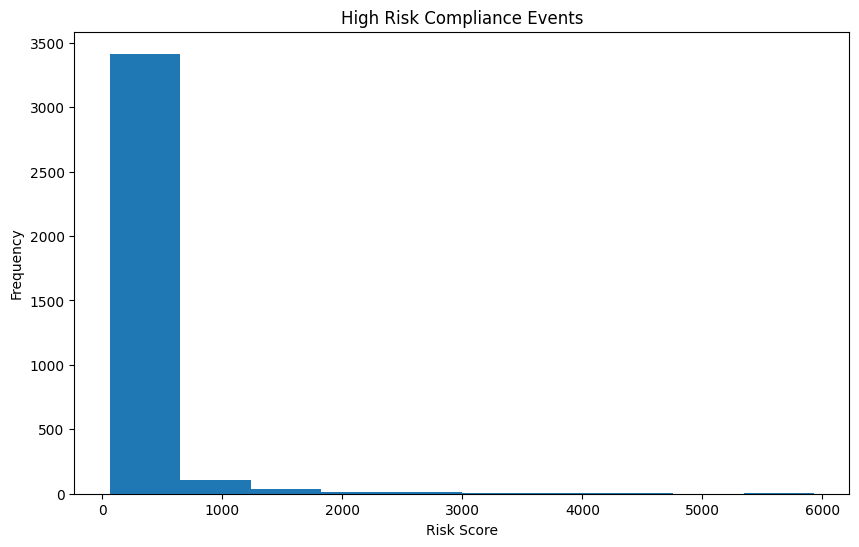

In [16]:
high_risk = compliance_data[
    compliance_data['risk_level'] == 'HIGH_RISK'
]

plt.figure(figsize=(10,6))

plt.hist(high_risk['risk_score'])

plt.title('High Risk Compliance Events')
plt.xlabel('Risk Score')
plt.ylabel('Frequency')

plt.show()

In [17]:
def lambda_handler(event, context):

    for record in event['Records']:

        log_data = json.loads(record['body'])

        failed_logins = log_data['failed_logins']
        location = log_data['location']

        risk_score = 0

        if failed_logins > 5:
            risk_score += 50

        if location not in ['US', 'CA']:
            risk_score += 30

        if risk_score >= 50:
            print('HIGH RISK EVENT DETECTED')

    return {
        'statusCode': 200
    }

In [20]:
import sqlite3

conn = sqlite3.connect('compliance.db')

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE compliance_events (
    user_id TEXT,
    failed_login_ratio REAL,
    transaction_velocity REAL,
    geo_risk INTEGER,
    anomaly_score REAL,
    risk_level TEXT
)
""")

conn.commit()

print("Table created successfully")

Table created successfully
